# InterLeaf AI Pipeline — Evaluation Only

This notebook evaluates saved predictions against `Reddit_250_Gold.xlsx`.

It is intentionally separate from the prediction notebook.

**Inputs**
- `Reddit_250_Gold.xlsx`
- `reddit_250_predictions.jsonl`

**Evaluation**
- RQ1: Safety detection
- RQ2: Ontology multi-label tagging
- RQ3: Free-form theme recovery
- RQ4: Confidence/reliability alignment

This notebook **never changes or regenerates model predictions**.

In [2]:
# Colab install cell, if needed:
# !pip install -q -U pandas numpy scipy scikit-learn openpyxl matplotlib sentence-transformers

## Setup

In [3]:
import os
import re
import json
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

from sentence_transformers import SentenceTransformer


GOLD_XLSX = Path("/content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/Reddit_250_Gold.xlsx")
GOLD_SHEET = "Annotations"
PRED_JSONL = Path("/content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/reddit_250_predictions.jsonl")

OUTDIR = Path("/content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs")
FIGDIR = OUTDIR / "figures"
OUTDIR.mkdir(exist_ok=True)
FIGDIR.mkdir(exist_ok=True)

DEFAULT_SAFETY_THRESHOLD = 0.80
FREEFORM_COSINE_THRESHOLD = 0.60
FREEFORM_ENCODER = "all-MiniLM-L6-v2"

DOMAINS = ("body_area", "symptom", "trigger", "coping", "emotion")

## Fixed ontology

In [4]:
ONTOLOGY = {
    "body_area": [
        "head", "neck", "shoulder", "back", "hip",
        "knee", "hands", "feet", "diffuse"
    ],
    "symptom": [
        "burning", "stabbing", "throbbing", "stiffness",
        "fatigue", "brain fog", "sleep trouble", "numbness", "tingling"
    ],
    "trigger": [
        "weather", "stress", "long sitting", "hormonal cycle",
        "certain foods", "overexertion", "poor sleep"
    ],
    "coping": [
        "pacing", "heat", "mindfulness", "medication",
        "physical therapy", "stretching", "TENS", "CBT skills", "rest breaks"
    ],
    "emotion": [
        "grief", "anger", "frustration", "shame",
        "hope", "acceptance", "overwhelm", "loneliness"
    ],
}


def canonical(x):
    if x is None:
        return ""
    return re.sub(r"\s+", " ", str(x).strip().lower())


ALL_ONTOLOGY_TAGS = [
    f"{domain}:{canonical(label)}"
    for domain, labels in ONTOLOGY.items()
    for label in labels
]

print("Ontology size:", len(ALL_ONTOLOGY_TAGS))

Ontology size: 42


## Parsing helpers

In [5]:
def split_pipe(value):
    if pd.isna(value) or not str(value).strip():
        return []
    return [
        canonical(x)
        for x in str(value).split("|")
        if canonical(x)
    ]


def safe_json_dict(value):
    if pd.isna(value) or not str(value).strip():
        return {}

    try:
        obj = json.loads(str(value))
        return obj if isinstance(obj, dict) else {}
    except Exception:
        return {}


def as_tag_strings(value):
    if value is None:
        return []

    if isinstance(value, str):
        return [canonical(value)] if canonical(value) else []

    if isinstance(value, dict):
        tag = canonical(value.get("tag"))
        return [tag] if tag else []

    if isinstance(value, list):
        out = []
        for item in value:
            if isinstance(item, str):
                tag = canonical(item)
            elif isinstance(item, dict):
                tag = canonical(item.get("tag"))
            else:
                tag = ""

            if tag:
                out.append(tag)

        return list(dict.fromkeys(out))

    return []

## Load gold annotations

In [6]:
DOMAIN_TAG_COLUMN = {
    "body_area": "body_area_tags_pipe",
    "symptom": "symptom_tags_pipe",
    "trigger": "trigger_tags_pipe",
    "coping": "coping_tags_pipe",
    "emotion": "emotion_tags_pipe",
}

DOMAIN_CONF_COLUMN = {
    "body_area": "body_area_confidence_json",
    "symptom": "symptom_confidence_json",
    "trigger": "trigger_confidence_json",
    "coping": "coping_confidence_json",
    "emotion": "emotion_confidence_json",
}


def load_gold(path=GOLD_XLSX, min_human_confidence=2):
    raw = pd.read_excel(path, sheet_name=GOLD_SHEET)

    if not raw["annotation_complete"].astype(str).str.lower().eq("yes").all():
        raise ValueError("Gold workbook contains incomplete rows.")

    rows = []

    for _, r in raw.iterrows():
        ontology_set = set()
        confidence_map = {}

        for domain in DOMAINS:
            tags = split_pipe(r[DOMAIN_TAG_COLUMN[domain]])
            conf = safe_json_dict(r[DOMAIN_CONF_COLUMN[domain]])

            normalized_conf = {
                canonical(k): int(v)
                for k, v in conf.items()
                if canonical(k)
            }

            for tag in tags:
                c = normalized_conf.get(tag, min_human_confidence)
                full = f"{domain}:{tag}"
                confidence_map[full] = c

                if c >= min_human_confidence:
                    ontology_set.add(full)

        freeform_tags = split_pipe(r["freeform_tags_pipe"])
        freeform_conf_raw = safe_json_dict(r["freeform_confidence_json"])
        freeform_conf = {
            canonical(k): int(v)
            for k, v in freeform_conf_raw.items()
            if canonical(k)
        }

        gold_freeform = {
            tag
            for tag in freeform_tags
            if freeform_conf.get(tag, min_human_confidence) >= min_human_confidence
        }

        rows.append({
            "post_id": str(r["post_id"]),
            "post_text": str(r["post_text"]),
            "gold_safety_label": canonical(r["safety_label"]),
            "gold_safety_confidence": int(r["safety_confidence_1to3"]),
            "gold_ontology_set": ontology_set,
            "gold_ontology_confidence": confidence_map,
            "gold_freeform_set": gold_freeform,
        })

    return pd.DataFrame(rows), raw


gold, gold_raw = load_gold()

print("Gold posts:", len(gold))
print(gold["gold_safety_label"].value_counts())

Gold posts: 250
gold_safety_label
not_harmful    235
harmful         15
Name: count, dtype: int64


## Load saved predictions

In [7]:
def load_predictions(path=PRED_JSONL):
    rows = []
    malformed = 0

    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                malformed += 1
                continue

            safety = obj.get("safety", {})
            if not isinstance(safety, dict):
                safety = {}

            pred_tags = {
                canonical(x)
                for x in obj.get("predicted_ontology_tags", [])
                if canonical(x)
            }

            confidence = {}
            raw_conf = obj.get("predicted_tag_confidence", {})

            if isinstance(raw_conf, dict):
                for tag, score in raw_conf.items():
                    tag = canonical(tag)
                    if not tag:
                        continue
                    try:
                        confidence[tag] = float(score)
                    except Exception:
                        pass

            rows.append({
                "post_id": str(obj.get("post_id")),
                "safety_score": float(safety.get("score", 0.0)),
                "saved_safety_label": canonical(safety.get("label")),
                "predicted_ontology_set": pred_tags,
                "predicted_tag_confidence": confidence,
                "candidate_freeform_tags": as_tag_strings(
                    obj.get("candidate_freeform_tags", [])
                ),
                "final_freeform_tags": as_tag_strings(
                    obj.get("final_freeform_tags", [])
                ),
                "final_tags": obj.get("final_tags", []),
            })

    if malformed:
        print(f"Warning: skipped {malformed} malformed JSONL lines.")

    pred = pd.DataFrame(rows)

    if pred["post_id"].duplicated().any():
        print("Warning: duplicate prediction IDs found; keeping the last record.")
        pred = pred.drop_duplicates("post_id", keep="last")

    return pred


pred = load_predictions()

df = gold.merge(pred, on="post_id", how="inner", validate="one_to_one")

print("Prediction records:", len(pred))
print("Matched gold/prediction posts:", len(df))

if len(df) != len(gold):
    missing = sorted(set(gold["post_id"]) - set(pred["post_id"]))
    raise ValueError(
        f"Missing predictions for {len(missing)} gold posts. "
        f"Examples: {missing[:10]}"
    )

Prediction records: 250
Matched gold/prediction posts: 250


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# RQ1 — Safety Detection

The harmful class is treated as positive.

The primary operating point is the **pre-specified threshold of 0.80**.  
A threshold sweep is retained as a diagnostic analysis.

In [9]:
def safety_metrics_at_threshold(data, threshold):
    y_true = data["gold_safety_label"].eq("harmful").to_numpy()
    scores = data["safety_score"].to_numpy(dtype=float)
    y_pred = scores >= threshold

    tp = int((y_pred & y_true).sum())
    fp = int((y_pred & ~y_true).sum())
    fn = int((~y_pred & y_true).sum())
    tn = int((~y_pred & ~y_true).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0.0
    )
    accuracy = (tp + tn) / len(data)

    return {
        "threshold": float(threshold),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def sweep_safety_thresholds(data, start=0.0, stop=1.0, step=0.01):
    thresholds = np.round(
        np.arange(start, stop + 1e-9, step),
        4,
    )
    return pd.DataFrame([
        safety_metrics_at_threshold(data, t)
        for t in thresholds
    ])


safety_sweep = sweep_safety_thresholds(df)

default_safety = safety_metrics_at_threshold(
    df,
    DEFAULT_SAFETY_THRESHOLD,
)

best_f1_row = safety_sweep.loc[
    safety_sweep["f1"].idxmax()
].to_dict()

print("Default threshold:")
print(default_safety)

print("\nDiagnostic best-F1 threshold:")
print(best_f1_row)

safety_sweep.to_csv(
    OUTDIR / "rq1_safety_threshold_sweep.csv",
    index=False,
)

Default threshold:
{'threshold': 0.8, 'precision': 1.0, 'recall': 0.2, 'f1': 0.33333333333333337, 'accuracy': 0.952, 'tp': 3, 'fp': 0, 'fn': 12, 'tn': 235}

Diagnostic best-F1 threshold:
{'threshold': 0.31, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692307692307693, 'accuracy': 0.964, 'tp': 15.0, 'fp': 9.0, 'fn': 0.0, 'tn': 226.0}


# RQ2 — Ontology Multi-Label Tagging

In [10]:
def tag_confusion(gold_sets, pred_sets, tag):
    tp = fp = fn = tn = 0

    for gold_set, pred_set in zip(gold_sets, pred_sets):
        gt = tag in gold_set
        pr = tag in pred_set

        if gt and pr:
            tp += 1
        elif not gt and pr:
            fp += 1
        elif gt and not pr:
            fn += 1
        else:
            tn += 1

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0.0
    )

    return {
        "tag": tag,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "gold_support": tp + fn,
    }


def jaccard(gold_set, pred_set):
    union = gold_set | pred_set
    if not union:
        return 1.0
    return len(gold_set & pred_set) / len(union)


def evaluate_ontology(data):
    gold_sets = data["gold_ontology_set"].tolist()
    pred_sets = data["predicted_ontology_set"].tolist()

    per_tag = pd.DataFrame([
        tag_confusion(gold_sets, pred_sets, tag)
        for tag in ALL_ONTOLOGY_TAGS
    ])

    supported = per_tag["gold_support"] > 0

    micro_tp = int(per_tag["tp"].sum())
    micro_fp = int(per_tag["fp"].sum())
    micro_fn = int(per_tag["fn"].sum())
    micro_tn = int(per_tag["tn"].sum())

    micro_p = (
        micro_tp / (micro_tp + micro_fp)
        if micro_tp + micro_fp else 0.0
    )
    micro_r = (
        micro_tp / (micro_tp + micro_fn)
        if micro_tp + micro_fn else 0.0
    )
    micro_f1 = (
        2 * micro_p * micro_r / (micro_p + micro_r)
        if micro_p + micro_r else 0.0
    )

    j_all = np.array([
        jaccard(g, p)
        for g, p in zip(gold_sets, pred_sets)
    ])

    nonempty_mask = np.array([
        bool(g | p)
        for g, p in zip(gold_sets, pred_sets)
    ])

    per_domain_rows = []

    for domain in DOMAINS:
        sub = per_tag[
            per_tag["tag"].str.startswith(domain + ":")
        ]
        sub_supported = sub[sub["gold_support"] > 0]

        per_domain_rows.append({
            "domain": domain,
            "supported_labels": len(sub_supported),
            "macro_precision": (
                sub_supported["precision"].mean()
                if len(sub_supported) else np.nan
            ),
            "macro_recall": (
                sub_supported["recall"].mean()
                if len(sub_supported) else np.nan
            ),
            "macro_f1": (
                sub_supported["f1"].mean()
                if len(sub_supported) else np.nan
            ),
        })

    per_domain = pd.DataFrame(per_domain_rows)

    summary = {
        "macro_precision_supported": float(
            per_tag.loc[supported, "precision"].mean()
        ),
        "macro_recall_supported": float(
            per_tag.loc[supported, "recall"].mean()
        ),
        "macro_f1_supported": float(
            per_tag.loc[supported, "f1"].mean()
        ),
        "supported_labels": int(supported.sum()),
        "micro_precision": float(micro_p),
        "micro_recall": float(micro_r),
        "micro_f1": float(micro_f1),
        "jaccard_mean_all_posts": float(j_all.mean()),
        "jaccard_std_all_posts": float(j_all.std(ddof=1)),
        "jaccard_mean_nonempty_union": float(
            j_all[nonempty_mask].mean()
        ) if nonempty_mask.any() else np.nan,
        "micro_confusion": {
            "tp": micro_tp,
            "fp": micro_fp,
            "fn": micro_fn,
            "tn": micro_tn,
        },
    }

    return summary, per_tag, per_domain


ontology_summary, per_tag_df, per_domain_df = evaluate_ontology(df)

print(ontology_summary)
print("\nPer-domain macro:")
print(per_domain_df.to_string(index=False))

per_tag_df.to_csv(
    OUTDIR / "rq2_per_tag_metrics.csv",
    index=False,
)
per_domain_df.to_csv(
    OUTDIR / "rq2_per_domain_metrics.csv",
    index=False,
)

{'macro_precision_supported': 0.7392987849509589, 'macro_recall_supported': 0.736973026973027, 'macro_f1_supported': 0.7197609782425106, 'supported_labels': 39, 'micro_precision': 0.8103448275862069, 'micro_recall': 0.7580645161290323, 'micro_f1': 0.7833333333333333, 'jaccard_mean_all_posts': 0.727, 'jaccard_std_all_posts': 0.3776333982707483, 'jaccard_mean_nonempty_union': 0.6407894736842106, 'micro_confusion': {'tp': 235, 'fp': 55, 'fn': 75, 'tn': 10135}}

Per-domain macro:
   domain  supported_labels  macro_precision  macro_recall  macro_f1
body_area                 9         0.782804      0.726275  0.739486
  symptom                 9         0.746296      0.751587  0.744388
  trigger                 6         0.695833      0.704167  0.668981
   coping                 7         0.618012      0.727619  0.655952
  emotion                 8         0.821208      0.765357  0.763782


# RQ3 — Free-Form Theme Recovery

This evaluation uses an **independent SentenceTransformer encoder**, not the Gemini embedding model used inside the pipeline.

Predictions are evaluated exactly as saved. No themes are synthesized, patched, or carried forward during evaluation.

In [25]:
freeform_model = SentenceTransformer(FREEFORM_ENCODER)


def encode_tags(tags):
    if not tags:
        return np.empty((0, 384))

    return freeform_model.encode(
        list(tags),
        convert_to_numpy=True,
        normalize_embeddings=True,
    )


def freeform_recall_for_post(gold_tags, predicted_tags):
    gold_tags = sorted(set(gold_tags))
    predicted_tags = list(dict.fromkeys(predicted_tags))

    if not gold_tags:
        return np.nan, 0, 0

    if not predicted_tags:
        return 0.0, 0, len(gold_tags)

    g = encode_tags(gold_tags)
    p = encode_tags(predicted_tags)

    similarities = g @ p.T
    matched = (
        similarities.max(axis=1)
        >= FREEFORM_COSINE_THRESHOLD
    )

    hits = int(matched.sum())
    total = len(gold_tags)

    return hits / total, hits, total


def evaluate_freeform_stage(data, prediction_column):
    subset = data[
        data["gold_freeform_set"].apply(len) > 0
    ]

    macro_recalls = []
    total_hits = 0
    total_gold = 0
    any_hit = 0

    for _, row in subset.iterrows():
        recall, hits, total = freeform_recall_for_post(
            row["gold_freeform_set"],
            row[prediction_column],
        )

        macro_recalls.append(recall)
        total_hits += hits
        total_gold += total

        if hits > 0:
            any_hit += 1

    n = len(subset)

    return {
        "eligible_posts": n,
        "any_hit_recall": any_hit / n if n else np.nan,
        "macro_recall": (
            float(np.mean(macro_recalls))
            if macro_recalls else np.nan
        ),
        "micro_recall": (
            total_hits / total_gold
            if total_gold else np.nan
        ),
        "gold_themes": total_gold,
        "matched_gold_themes": total_hits,
        "cosine_threshold": FREEFORM_COSINE_THRESHOLD,
        "encoder": FREEFORM_ENCODER,
    }


freeform_candidate = evaluate_freeform_stage(
    df,
    "candidate_freeform_tags",
)

freeform_final = evaluate_freeform_stage(
    df,
    "final_freeform_tags",
)

print("Candidate stage:")
print(freeform_candidate)

print("\nFinal stage:")
print(freeform_final)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Candidate stage:
{'eligible_posts': 37, 'any_hit_recall': 0.7027027027027027, 'macro_recall': 0.6891891891891891, 'micro_recall': 0.6444444444444445, 'gold_themes': 45, 'matched_gold_themes': 29, 'cosine_threshold': 0.6, 'encoder': 'all-MiniLM-L6-v2'}

Final stage:
{'eligible_posts': 37, 'any_hit_recall': 0.7027027027027027, 'macro_recall': 0.6891891891891891, 'micro_recall': 0.6444444444444445, 'gold_themes': 45, 'matched_gold_themes': 29, 'cosine_threshold': 0.6, 'encoder': 'all-MiniLM-L6-v2'}


# RQ4 — Confidence Alignment and Reliability

In [12]:
def confidence_band_table(scores, correct):
    scores = np.asarray(scores, dtype=float)
    correct = np.asarray(correct, dtype=float)

    if len(scores) == 0:
        return pd.DataFrame(
            columns=["band", "n", "correctness", "mean_confidence"]
        )

    order = np.argsort(scores)
    k = max(1, len(scores) // 4)

    low_idx = order[:k]
    high_idx = order[-k:]
    mid_idx = order[k:-k]

    rows = []

    for band, idx in [
        ("low", low_idx),
        ("medium", mid_idx),
        ("high", high_idx),
    ]:
        rows.append({
            "band": band,
            "n": len(idx),
            "correctness": (
                float(correct[idx].mean())
                if len(idx) else np.nan
            ),
            "mean_confidence": (
                float(scores[idx].mean())
                if len(idx) else np.nan
            ),
        })

    return pd.DataFrame(rows)


def evaluate_confidence(data):
    # Safety confidence in the predicted class.
    safety_scores = []
    safety_correct = []

    for _, row in data.iterrows():
        harmful_score = float(row["safety_score"])
        pred_harmful = harmful_score >= DEFAULT_SAFETY_THRESHOLD

        class_confidence = (
            harmful_score
            if pred_harmful
            else 1.0 - harmful_score
        )

        gold_harmful = row["gold_safety_label"] == "harmful"

        safety_scores.append(class_confidence)
        safety_correct.append(float(pred_harmful == gold_harmful))

    safety_bands = confidence_band_table(
        safety_scores,
        safety_correct,
    )

    # Ontology confidence on predicted final ontology tags.
    ontology_scores = []
    ontology_correct = []
    model_human_pairs = []

    for _, row in data.iterrows():
        gold_set = row["gold_ontology_set"]
        human_conf = row["gold_ontology_confidence"]

        for tag, score in row["predicted_tag_confidence"].items():
            ontology_scores.append(float(score))
            ontology_correct.append(float(tag in gold_set))

            if tag in human_conf:
                model_human_pairs.append(
                    (float(score), int(human_conf[tag]))
                )

    ontology_bands = confidence_band_table(
        ontology_scores,
        ontology_correct,
    )

    if (
        len(model_human_pairs) >= 3
        and len(set(x[0] for x in model_human_pairs)) > 1
        and len(set(x[1] for x in model_human_pairs)) > 1
    ):
        rho, p_value = spearmanr(
            [x[0] for x in model_human_pairs],
            [x[1] for x in model_human_pairs],
        )
        rho = float(rho)
        p_value = float(p_value)
    else:
        rho = np.nan
        p_value = np.nan

    return {
        "safety_bands": safety_bands,
        "ontology_bands": ontology_bands,
        "spearman_rho_model_vs_human": rho,
        "spearman_p_value": p_value,
        "n_model_human_pairs": len(model_human_pairs),
    }


confidence_results = evaluate_confidence(df)

print("Safety confidence bands:")
print(confidence_results["safety_bands"].to_string(index=False))

print("\nOntology confidence bands:")
print(confidence_results["ontology_bands"].to_string(index=False))

print("\nSpearman rho:")
print(confidence_results["spearman_rho_model_vs_human"])
print("n pairs:", confidence_results["n_model_human_pairs"])

confidence_results["safety_bands"].to_csv(
    OUTDIR / "rq4_safety_confidence_bands.csv",
    index=False,
)

confidence_results["ontology_bands"].to_csv(
    OUTDIR / "rq4_ontology_confidence_bands.csv",
    index=False,
)

Safety confidence bands:
  band   n  correctness  mean_confidence
   low  62     0.806452         0.647884
medium 126     1.000000         0.854019
  high  62     1.000000         0.944429

Ontology confidence bands:
  band   n  correctness  mean_confidence
   low  72     0.527778         0.630336
medium 146     0.856164         0.793566
  high  72     1.000000         0.912719

Spearman rho:
0.10201190110058335
n pairs: 235


# Figures

In [13]:
def save_figure(fig, filename):
    path = FIGDIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", path)

## Figure — Safety precision/recall threshold sweep

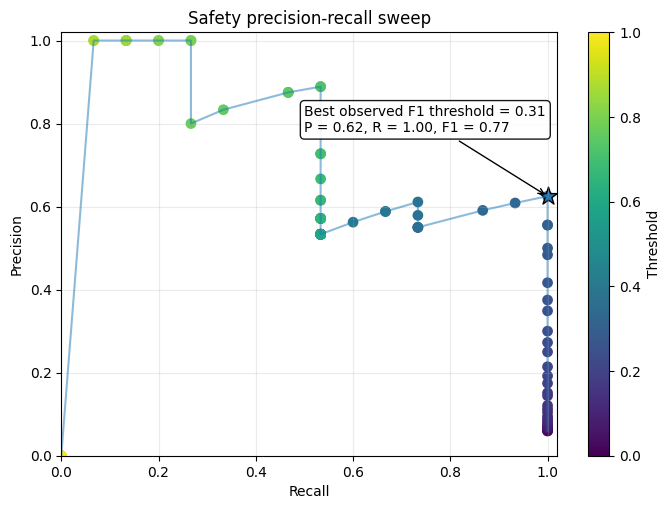

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/rq1_safety_precision_recall_sweep.png


In [28]:
def plot_safety_sweep(sweep):
    best = sweep.loc[sweep["f1"].idxmax()]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    scatter = ax.scatter(
        sweep["recall"],
        sweep["precision"],
        c=sweep["threshold"],
        s=45,
    )

    ax.plot(
        sweep["recall"],
        sweep["precision"],
        linewidth=1.5,
        alpha=0.5,
    )

    ax.scatter(
        [best["recall"]],
        [best["precision"]],
        marker="*",
        s=180,
        edgecolors="black",
    )

    ax.annotate(
        (
            f"Best observed F1 threshold = {best['threshold']:.2f}\n"
            f"P = {best['precision']:.2f}, "
            f"R = {best['recall']:.2f}, "
            f"F1 = {best['f1']:.2f}"
        ),
        xy=(best["recall"], best["precision"]),
        xytext=(-175, 55),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.0,
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.9,
        ),
    )

    fig.colorbar(scatter, ax=ax, label="Threshold")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Safety precision-recall sweep")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)

    save_figure(fig, "rq1_safety_precision_recall_sweep.png")


plot_safety_sweep(safety_sweep)

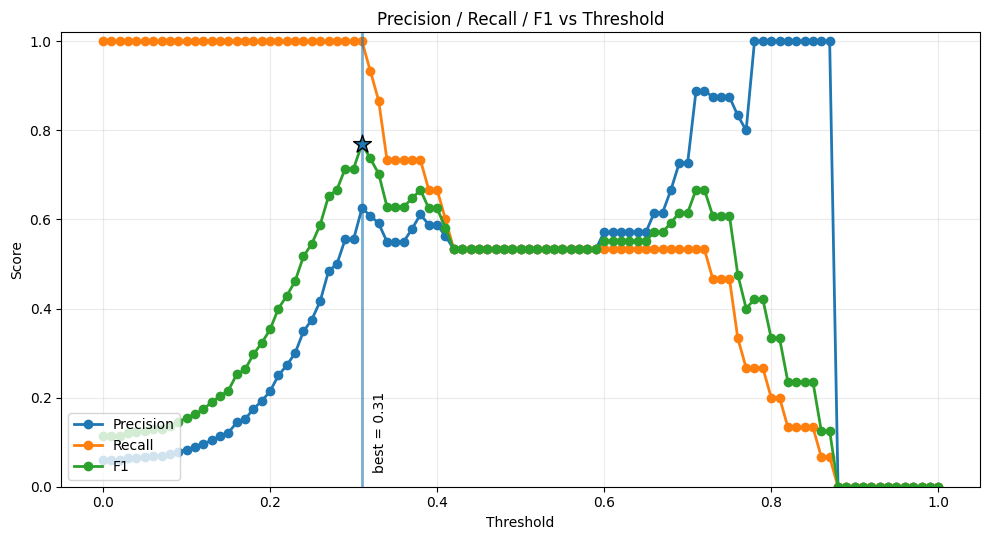

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/rq1_safety_metrics_vs_threshold.png


In [30]:
def plot_safety_metrics_vs_threshold(sweep):
    # Find threshold with best observed F1
    best = sweep.loc[sweep["f1"].idxmax()]

    fig, ax = plt.subplots(figsize=(10, 5.5))

    # Plot precision, recall, and F1
    ax.plot(
        sweep["threshold"],
        sweep["precision"],
        marker="o",
        linewidth=2,
        label="Precision",
    )

    ax.plot(
        sweep["threshold"],
        sweep["recall"],
        marker="o",
        linewidth=2,
        label="Recall",
    )

    ax.plot(
        sweep["threshold"],
        sweep["f1"],
        marker="o",
        linewidth=2,
        label="F1",
    )

    # Vertical line at best-F1 threshold
    ax.axvline(
        best["threshold"],
        linewidth=2,
        alpha=0.6,
    )

    # Star marking best F1 point
    ax.scatter(
        [best["threshold"]],
        [best["f1"]],
        marker="*",
        s=180,
        edgecolors="black",
        zorder=5,
    )

    # Threshold label
    ax.annotate(
        f"best = {best['threshold']:.2f}",
        xy=(best["threshold"], 0.03),
        xytext=(8, 0),
        textcoords="offset points",
        rotation=90,
        ha="left",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title("Precision / Recall / F1 vs Threshold")

    ax.set_ylim(0, 1.02)

    # Add a little horizontal padding
    xmin = sweep["threshold"].min()
    xmax = sweep["threshold"].max()
    padding = (xmax - xmin) * 0.05

    ax.set_xlim(
        xmin - padding,
        xmax + padding
    )

    ax.legend(loc="lower left")
    ax.grid(alpha=0.25)

    fig.tight_layout()

    save_figure(
        fig,
        "rq1_safety_metrics_vs_threshold.png"
    )


plot_safety_metrics_vs_threshold(safety_sweep)

## Figure — Macro vs. micro ontology performance

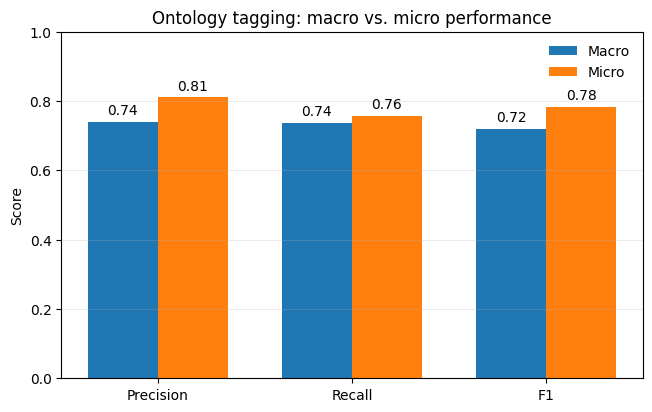

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/rq2_macro_vs_micro.png


In [15]:
def plot_macro_micro(ontology_summary):
    macro = [
        ontology_summary["macro_precision_supported"],
        ontology_summary["macro_recall_supported"],
        ontology_summary["macro_f1_supported"],
    ]

    micro = [
        ontology_summary["micro_precision"],
        ontology_summary["micro_recall"],
        ontology_summary["micro_f1"],
    ]

    labels = ["Precision", "Recall", "F1"]
    x = np.arange(len(labels))
    width = 0.36

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    b1 = ax.bar(x - width / 2, macro, width, label="Macro")
    b2 = ax.bar(x + width / 2, micro, width, label="Micro")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.set_title("Ontology tagging: macro vs. micro performance")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)

    ax.bar_label(b1, fmt="%.2f", padding=3)
    ax.bar_label(b2, fmt="%.2f", padding=3)

    save_figure(fig, "rq2_macro_vs_micro.png")


plot_macro_micro(ontology_summary)

## Figure — Confidence bands vs. reliability

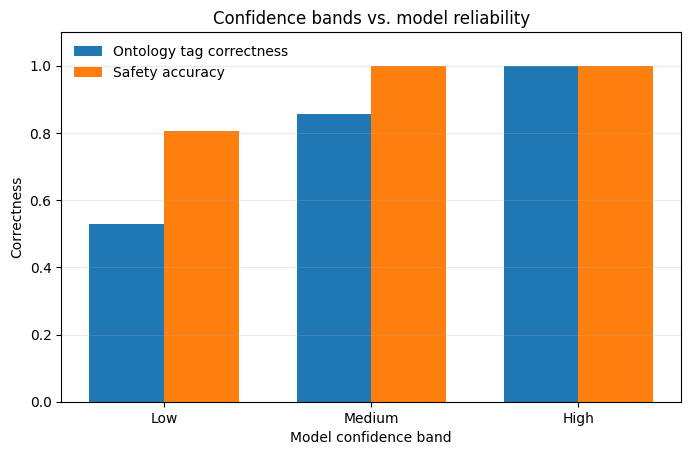

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/rq4_confidence_bands.png


In [29]:
def plot_confidence_bands(confidence_results):
    safety = confidence_results["safety_bands"].set_index("band")
    ontology = confidence_results["ontology_bands"].set_index("band")

    bands = ["low", "medium", "high"]

    safety_values = [
        safety.loc[b, "correctness"] if b in safety.index else np.nan
        for b in bands
    ]

    ontology_values = [
        ontology.loc[b, "correctness"] if b in ontology.index else np.nan
        for b in bands
    ]

    x = np.arange(len(bands))
    width = 0.36

    fig, ax = plt.subplots(figsize=(8, 4.8))

    b1 = ax.bar(
        x - width / 2,
        ontology_values,
        width,
        label="Ontology tag correctness",
    )

    b2 = ax.bar(
        x + width / 2,
        safety_values,
        width,
        label="Safety accuracy",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["Low", "Medium", "High"])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Correctness")
    ax.set_xlabel("Model confidence band")
    ax.set_title("Confidence bands vs. model reliability")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)

    save_figure(fig, "rq4_confidence_bands.png")


plot_confidence_bands(confidence_results)

# Gold Dataset Characterization Figures

In [17]:
gold_plot = gold_raw.copy()

gold_plot["word_count"] = (
    gold_plot["post_text"]
    .astype(str)
    .str.findall(r"\b\w+\b")
    .str.len()
)

for domain, col in DOMAIN_TAG_COLUMN.items():
    gold_plot[f"{domain}_tags"] = gold_plot[col].apply(split_pipe)

## Safety label distribution

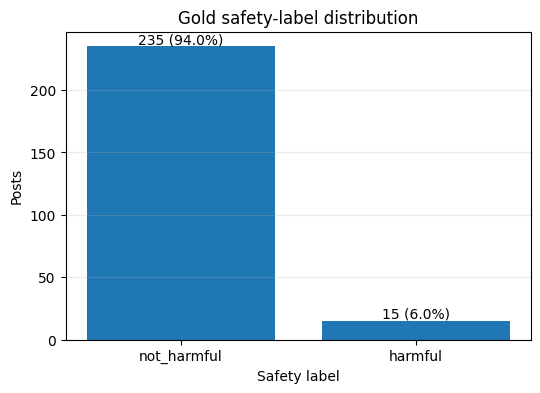

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_safety_distribution.png


In [18]:
counts = gold_plot["safety_label"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index.astype(str), counts.values)

for bar in bars:
    value = int(bar.get_height())
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value} ({value / len(gold_plot) * 100:.1f}%)",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("Safety label")
ax.set_ylabel("Posts")
ax.set_title("Gold safety-label distribution")
ax.grid(axis="y", alpha=0.25)

save_figure(fig, "dataset_safety_distribution.png")

## Post length by safety label

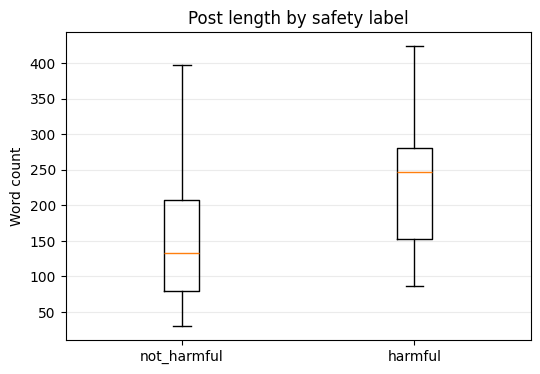

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_wordcount_by_safety.png


In [19]:
labels = ["not_harmful", "harmful"]

values = [
    gold_plot.loc[
        gold_plot["safety_label"] == label,
        "word_count",
    ].to_numpy()
    for label in labels
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(values, tick_labels=labels, showfliers=False)

ax.set_ylabel("Word count")
ax.set_title("Post length by safety label")
ax.grid(axis="y", alpha=0.25)

save_figure(fig, "dataset_wordcount_by_safety.png")

## Ontology-domain coverage

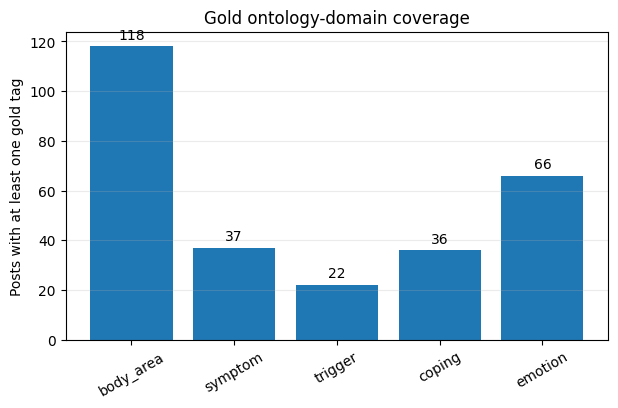

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_domain_coverage.png


In [20]:
domain_coverage = {
    domain: gold_plot[f"{domain}_tags"].apply(bool).sum()
    for domain in DOMAINS
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    list(domain_coverage.keys()),
    list(domain_coverage.values()),
)

ax.bar_label(bars, padding=3)
ax.set_ylabel("Posts with at least one gold tag")
ax.set_title("Gold ontology-domain coverage")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)

save_figure(fig, "dataset_domain_coverage.png")

## Body-area tags by safety label

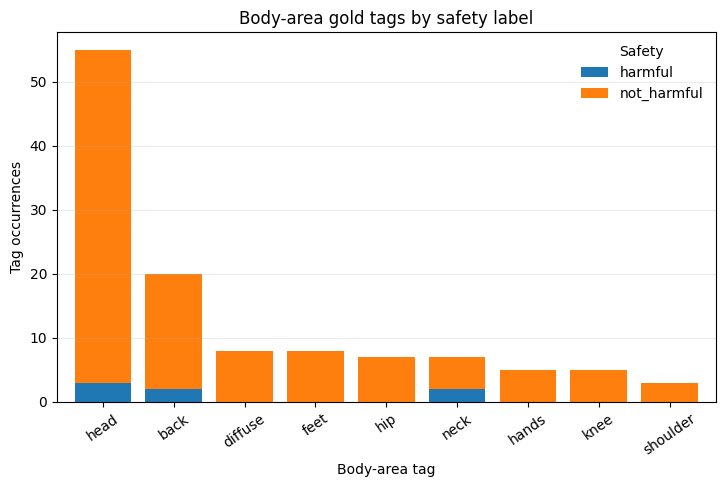

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_bodyarea_by_safety.png


In [21]:
records = []

for _, row in gold_plot.iterrows():
    for tag in row["body_area_tags"]:
        records.append({
            "tag": tag,
            "safety": row["safety_label"],
        })

body_long = pd.DataFrame(records)

if len(body_long):
    table = pd.crosstab(
        body_long["tag"],
        body_long["safety"],
    )

    order = table.sum(axis=1).sort_values(
        ascending=False
    ).index

    table = table.loc[order]

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    table.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.8,
    )

    ax.set_xlabel("Body-area tag")
    ax.set_ylabel("Tag occurrences")
    ax.set_title("Body-area gold tags by safety label")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Safety", frameon=False)
    ax.grid(axis="y", alpha=0.25)

    save_figure(fig, "dataset_bodyarea_by_safety.png")

## Top tags by domain

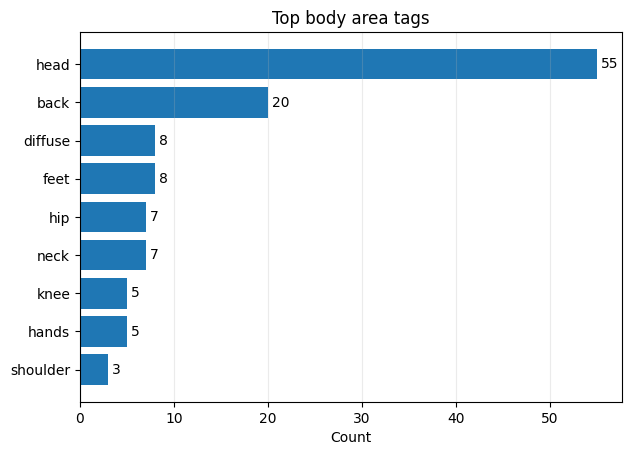

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_top_body_area_tags.png


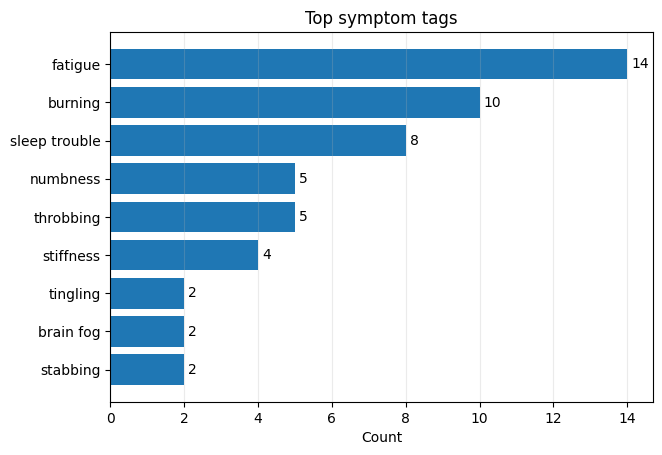

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_top_symptom_tags.png


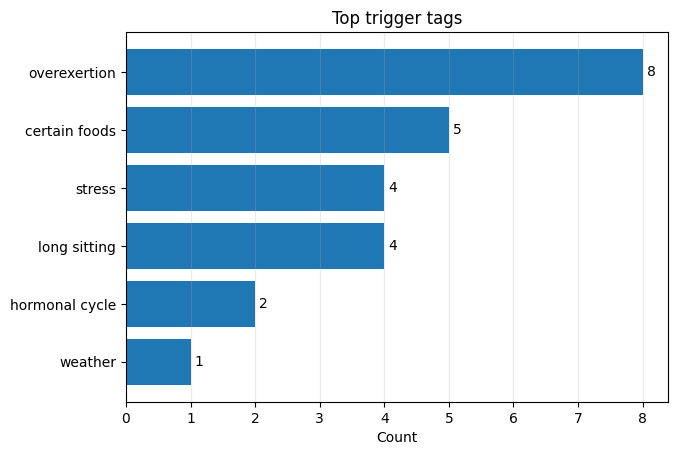

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_top_trigger_tags.png


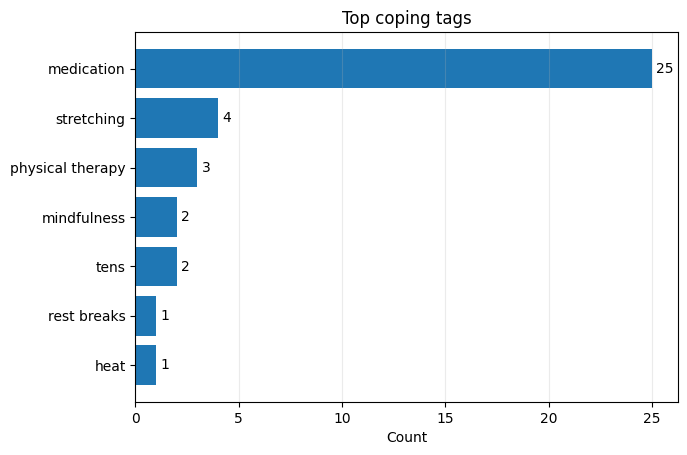

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_top_coping_tags.png


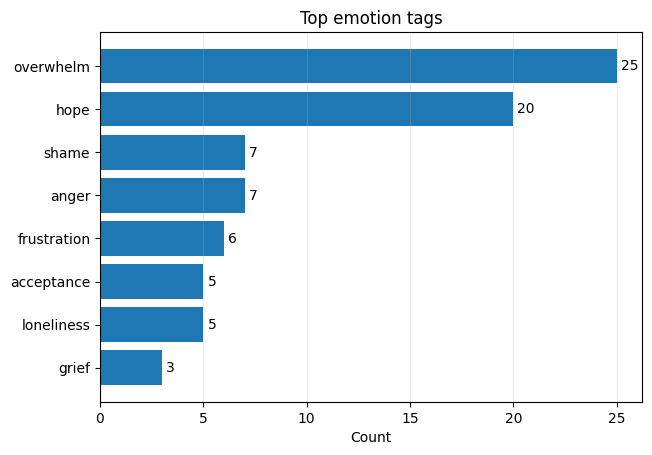

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_top_emotion_tags.png


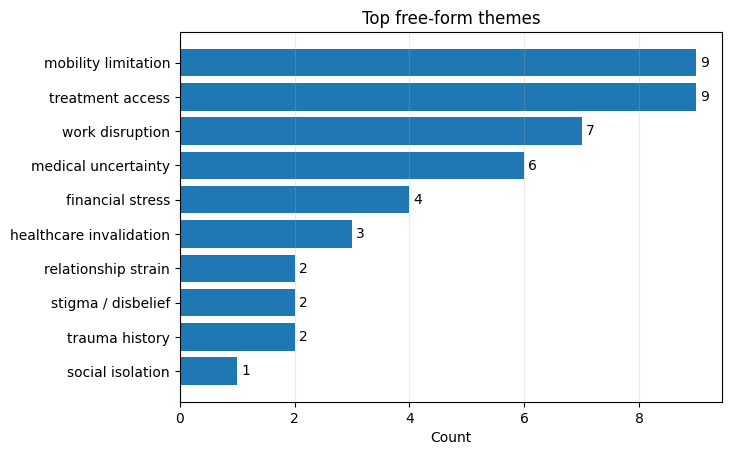

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_top_freeform_themes.png


In [22]:
def plot_top_tags(domain, top_n=12):
    tags = [
        tag
        for values in gold_plot[f"{domain}_tags"]
        for tag in values
    ]

    counts = pd.Series(tags).value_counts().head(top_n).sort_values()

    if counts.empty:
        return

    fig, ax = plt.subplots(figsize=(7, 4.8))
    bars = ax.barh(counts.index, counts.values)

    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Count")
    ax.set_title(f"Top {domain.replace('_', ' ')} tags")
    ax.grid(axis="x", alpha=0.25)

    save_figure(fig, f"dataset_top_{domain}_tags.png")


for domain in DOMAINS:
    plot_top_tags(domain)

freeform_tags = [
    tag
    for value in gold_plot["freeform_tags_pipe"]
    for tag in split_pipe(value)
]

if freeform_tags:
    counts = pd.Series(
        freeform_tags
    ).value_counts().head(12).sort_values()

    fig, ax = plt.subplots(figsize=(7, 4.8))
    bars = ax.barh(counts.index, counts.values)
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Count")
    ax.set_title("Top free-form themes")
    ax.grid(axis="x", alpha=0.25)
    save_figure(fig, "dataset_top_freeform_themes.png")

## Emotion co-occurrence

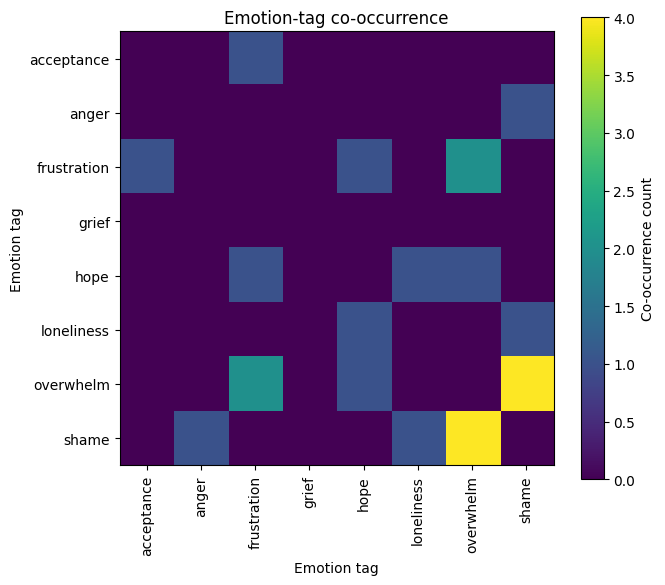

Saved: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs/figures/dataset_emotion_cooccurrence.png


In [23]:
emotion_lists = gold_plot["emotion_tags"]

emotions = sorted(
    set(
        tag
        for tags in emotion_lists
        for tag in tags
    )
)

index = {tag: i for i, tag in enumerate(emotions)}
matrix = np.zeros(
    (len(emotions), len(emotions)),
    dtype=int,
)

for tags in emotion_lists:
    unique = sorted(set(tags))

    for a, b in combinations(unique, 2):
        i, j = index[a], index[b]
        matrix[i, j] += 1
        matrix[j, i] += 1

if emotions:
    fig, ax = plt.subplots(figsize=(7, 6))

    image = ax.imshow(
        matrix,
        interpolation="nearest",
    )

    ax.set_xticks(range(len(emotions)))
    ax.set_yticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=90)
    ax.set_yticklabels(emotions)

    ax.set_xlabel("Emotion tag")
    ax.set_ylabel("Emotion tag")
    ax.set_title("Emotion-tag co-occurrence")

    fig.colorbar(
        image,
        ax=ax,
        label="Co-occurrence count",
    )

    save_figure(fig, "dataset_emotion_cooccurrence.png")

# Export evaluation summary

In [26]:
summary = {
    "n_posts": len(df),
    "rq1_safety_default_threshold": default_safety,
    "rq1_safety_best_f1_diagnostic": {
        key: (
            float(value)
            if isinstance(value, (np.floating, float))
            else int(value)
            if isinstance(value, (np.integer, int))
            else value
        )
        for key, value in best_f1_row.items()
    },
    "rq2_ontology": ontology_summary,
    "rq3_freeform_candidate": freeform_candidate,
    "rq3_freeform_final": freeform_final,
    "rq4": {
        "spearman_rho_model_vs_human": (
            None
            if pd.isna(
                confidence_results["spearman_rho_model_vs_human"]
            )
            else confidence_results[
                "spearman_rho_model_vs_human"
            ]
        ),
        "spearman_p_value": (
            None
            if pd.isna(confidence_results["spearman_p_value"])
            else confidence_results["spearman_p_value"]
        ),
        "n_model_human_pairs": confidence_results[
            "n_model_human_pairs"
        ],
    },
}

with (OUTDIR / "evaluation_summary.json").open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False,
    )

merged_export = df.copy()

merged_export["gold_ontology_tags"] = merged_export[
    "gold_ontology_set"
].apply(lambda x: "|".join(sorted(x)))

merged_export["predicted_ontology_tags"] = merged_export[
    "predicted_ontology_set"
].apply(lambda x: "|".join(sorted(x)))

merged_export["gold_freeform_tags"] = merged_export[
    "gold_freeform_set"
].apply(lambda x: "|".join(sorted(x)))

merged_export["candidate_freeform_tags"] = merged_export[
    "candidate_freeform_tags"
].apply(lambda x: "|".join(x))

merged_export["final_freeform_tags"] = merged_export[
    "final_freeform_tags"
].apply(lambda x: "|".join(x))

merged_export = merged_export.drop(
    columns=[
        "gold_ontology_set",
        "gold_ontology_confidence",
        "gold_freeform_set",
        "predicted_ontology_set",
        "predicted_tag_confidence",
        "final_tags",
    ],
    errors="ignore",
)

merged_export.to_csv(
    OUTDIR / "gold_plus_predictions.csv",
    index=False,
)

print("Evaluation outputs saved to:", OUTDIR.resolve())

Evaluation outputs saved to: /content/drive/MyDrive/Pubs/InterLeaf/3- Reddit AI Eval/evaluation_outputs


## Methodological changes from the older evaluation notebook

This version keeps the same four evaluation questions but removes three problematic behaviors from the older code:

1. **No prediction patching during evaluation.**  
   The older notebook constructed new "improved" free-form themes from ontology outputs. That changes the system after prediction and should not be part of evaluation.

2. **No filtering away ontology false positives simply because a label is absent from the gold sample.**  
   The full predefined ontology is the evaluation space. Macro averages are also reported over labels with gold support so unsupported labels do not dominate the macro score.

3. **Safety thresholding uses the saved harmful score directly.**  
   The new prediction format does not use the older `explicit_harm` field.

The evaluation notebook therefore scores the frozen prediction file as it actually exists.